# Model 2 — Peak lactate prediction

This notebook tests whether features extracted from the SmO₂ signal during a 30-second Wingate test can predict the amplitude of the lactate peak.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1) CONFIGURATION

CSV_FILES = {
    "Alexis": "../DATA/Alexis_wingate.csv",
    "Antoine": "../DATA/Antoine_wingate.csv",
    "Jinwei": "../DATA/Jinwei_wingate.csv",
    "Victor": "../DATA/Victor_wingate.csv",
}

XLS_FILE = "../DATA/Physio_Session2_Wingate.xlsx"
SHEET_NAME = "data"

WINGATE_DURATION = 30
BASELINE_BEFORE = 15
SLOPE_WINDOW = 10


## Data processing

The SmO₂ signal is cleaned and aligned with the lactate data.  
Only the 30-second Wingate period is used to extract the variables used in the model.

In [4]:
# 2) HELPER FUNCTIONS

def parse_sync_to_seconds(sync_val, recording_max=None):
    """
    Convert synchronization value to seconds.

    Handles:
    - numeric values
    - 'mm:ss'
    - 'hh:mm:ss'
    """
    if pd.isna(sync_val):
        raise ValueError("Empty synchronization value")

    try:
        return float(sync_val)
    except Exception:
        pass

    s = str(sync_val).strip()

    if ":" in s:
        parts = [float(x) for x in s.split(":")]
        if len(parts) == 2:
            mm, ss = parts
            return mm * 60 + ss
        elif len(parts) == 3:
            hh, mm, ss = parts
            return hh * 3600 + mm * 60 + ss

    raise ValueError(f"Unknown synchronization format: {sync_val}")


def load_trainred_csv(file_path):
    """
    Load a Train.Red CSV file and return a clean DataFrame with:
    - Time (seconds)
    - SmO2 (%)
    """
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = None
    for i, line in enumerate(lines):
        if "Timestamp (seconds passed)" in line and "SmO2" in line:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError(f"Header not found in {file_path}")

    df = pd.read_csv(file_path, skiprows=header_idx)
    df.columns = [str(c).strip() for c in df.columns]

    df = df[["Timestamp (seconds passed)", "SmO2"]].copy()
    df.columns = ["Time", "SmO2"]

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["SmO2"] = pd.to_numeric(df["SmO2"], errors="coerce")

    df = df.dropna(subset=["Time", "SmO2"]).sort_values("Time").reset_index(drop=True)
    return df


def smo2_desat_model(t, A, tau):
    """
    Exponential desaturation model:
    dSmO2(t) = A * (1 - exp(-t/tau))
    """
    return A * (1 - np.exp(-t / tau))


def fit_smo2_tau(win, sm0):
    """
    Fit SmO2 desaturation with an exponential model.

    Returns:
    - A_fit: desaturation amplitude
    - tau_fit: time constant
    """
    t = win["t_rel"].to_numpy(dtype=float)
    y = win["dSmO2"].to_numpy(dtype=float)

    if np.nanmax(y) < 0.5:
        return np.nan, np.nan

    try:
        p0 = [np.nanmax(y), 5.0]
        bounds = ([0.0, 0.1], [50.0, 60.0])

        popt, _ = curve_fit(
            smo2_desat_model,
            t,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        return float(popt[0]), float(popt[1])

    except Exception:
        return np.nan, np.nan


## Feature extraction

Several simple features are computed from the SmO₂ signal:
- total desaturation (AUC),
- maximal drop,
- early slope,
- time constant (τ).

These variables describe the magnitude and speed of muscular oxygen desaturation during the test.

In [5]:
def extract_wingate_window(sm_df, start_time_s):
    """
    Extract the Wingate window and compute SmO2 features.
    """
    sm = sm_df.copy()

    baseline_df = sm[(sm["Time"] >= start_time_s - BASELINE_BEFORE) &
                     (sm["Time"] < start_time_s)]

    if baseline_df.empty:
        baseline_df = sm[sm["Time"] < start_time_s]

    if baseline_df.empty:
        raise ValueError("No baseline available")

    sm0 = float(baseline_df["SmO2"].mean())

    win = sm[(sm["Time"] >= start_time_s) &
             (sm["Time"] <= start_time_s + WINGATE_DURATION)].copy()

    if len(win) < 5:
        raise ValueError("Wingate window too short")

    win["t_rel"] = win["Time"] - start_time_s
    win["dSmO2"] = (sm0 - win["SmO2"]).clip(lower=0)

    dt = float(np.mean(np.diff(win["Time"])))
    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Invalid dt inside Wingate window")

    auc_30 = float(np.sum(win["dSmO2"]) * dt)
    min_smo2 = float(win["SmO2"].min())
    dmax = float(win["dSmO2"].max())

    early = win[win["t_rel"] <= SLOPE_WINDOW].copy()
    if len(early) >= 3:
        slope = float(np.polyfit(early["t_rel"], early["SmO2"], 1)[0])
    else:
        slope = np.nan

    A_fit, tau_fit = fit_smo2_tau(win, sm0)
    t_half = tau_fit * np.log(2) if np.isfinite(tau_fit) else np.nan

    return {
        "sm_window": win,
        "SmO2_baseline": sm0,
        "AUC_30s": auc_30,
        "SmO2_min": min_smo2,
        "dSmO2_max": dmax,
        "slope_0_10": slope,
        "A_fit": A_fit,
        "tau_SmO2": tau_fit,
        "t_half_SmO2": t_half
    }


def summarize_lactate_subject(lac_subject):
    """
    Extract key lactate variables from one subject:
    - baseline lactate
    - peak lactate
    - time to peak
    - delta peak
    """
    lac_subject = lac_subject.sort_values("Time").copy()

    base_row = lac_subject[lac_subject["Time"] == -1]
    if base_row.empty:
        raise ValueError("No baseline lactate found (Time == -1)")
    la_baseline = float(base_row["[La]"].iloc[0])

    effort_row = lac_subject[lac_subject["Time"] == 0]
    la_effort0 = float(effort_row["[La]"].iloc[0]) if not effort_row.empty else np.nan

    post = lac_subject[lac_subject["Time"] > 0]
    if post.empty:
        raise ValueError("No post-exercise lactate data found")

    idx_peak = post["[La]"].idxmax()
    la_peak = float(post.loc[idx_peak, "[La]"])
    t_peak = float(post.loc[idx_peak, "Time"])

    delta_peak = la_peak - la_baseline

    return {
        "La_baseline": la_baseline,
        "La_effort0": la_effort0,
        "La_peak": la_peak,
        "Time_peak_min": t_peak,
        "Delta_La_peak": delta_peak
    }


# 3) LOAD LACTATE DATA

lac_all = pd.read_excel(XLS_FILE, sheet_name=SHEET_NAME)
lac_all.columns = [str(c).strip() for c in lac_all.columns]

required_cols = ["Name", "Time", "[La]", "Synchro SmO2"]
for c in required_cols:
    if c not in lac_all.columns:
        raise ValueError(f"Missing column in Excel file: {c}")

lac_all["Time"] = pd.to_numeric(lac_all["Time"], errors="coerce")
lac_all["[La]"] = pd.to_numeric(lac_all["[La]"], errors="coerce")


# 4) FEATURE EXTRACTION

rows = []

for subject, csv_file in CSV_FILES.items():
    sm = load_trainred_csv(csv_file)

    lac_sub = lac_all[lac_all["Name"].str.lower() == subject.lower()].copy()
    if lac_sub.empty:
        print(f"{subject}: not found in Excel file")
        continue

    sync_val = lac_sub["Synchro SmO2"].dropna().iloc[0]
    start_time_s = parse_sync_to_seconds(sync_val)

    sm_feat = extract_wingate_window(sm, start_time_s)
    la_feat = summarize_lactate_subject(lac_sub)

    row = {
        "id": subject,
        **{k: v for k, v in sm_feat.items() if k != "sm_window"},
        **la_feat
    }

    rows.append(row)

feat_df = pd.DataFrame(rows)

print("\n===== FEATURE TABLE =====")
print(feat_df[[
    "id",
    "AUC_30s",
    "SmO2_min",
    "dSmO2_max",
    "slope_0_10",
    "tau_SmO2",
    "La_baseline",
    "La_peak",
    "Delta_La_peak"
]])



===== FEATURE TABLE =====
        id     AUC_30s  SmO2_min  dSmO2_max  slope_0_10  tau_SmO2  \
0   Alexis  210.286007     60.68   9.623775   -0.551072  7.022233   
1  Antoine  372.110247     61.89  15.782467   -0.301603  5.300891   
2   Jinwei  155.060200     61.67   6.302000   -0.114292  0.100000   
3   Victor  210.286007     60.68   9.623775   -0.551072  7.022233   

   La_baseline  La_peak  Delta_La_peak  
0         1.70     16.1          14.40  
1         2.20     17.3          15.10  
2         2.50     13.9          11.40  
3         0.75     13.1          12.35  


## Model

A linear regression is used to predict the increase in lactate from baseline to peak (Δ lactate peak) from SmO₂ features.

Peak lactate is then obtained by adding the predicted increase to the measured baseline lactate.

In [6]:
# 5) MODEL 2 — PEAK LACTATE INCREASE

# We predict Delta_La_peak first, which is physiologically cleaner.
model2_cols = ["AUC_30s", "tau_SmO2", "dSmO2_max", "slope_0_10"]

df_m2 = feat_df.dropna(subset=model2_cols + ["Delta_La_peak"]).copy()

X2 = df_m2[model2_cols].to_numpy(float)
y2 = df_m2["Delta_La_peak"].to_numpy(float)

model2 = LinearRegression()
model2.fit(X2, y2)

df_m2["delta_peak_pred"] = model2.predict(X2)
df_m2["La_peak_pred"] = df_m2["La_baseline"] + df_m2["delta_peak_pred"]

# metrics for delta peak
rmse2 = float(np.sqrt(mean_squared_error(y2, df_m2["delta_peak_pred"])))
r2_2 = float(r2_score(y2, df_m2["delta_peak_pred"]))
r2corr = float(np.corrcoef(y2, df_m2["delta_peak_pred"])[0, 1])

print("\n===== MODEL 2 — DELTA PEAK LACTATE =====")
print("Variables :", model2_cols)
print("Intercept :", round(model2.intercept_, 4))
print("Coefficients :", {c: round(v, 6) for c, v in zip(model2_cols, model2.coef_)})
print(f"RMSE = {rmse2:.3f} mmol/L")
print(f"R²   = {r2_2:.3f}")
print(f"R    = {r2corr:.3f}")


# 6) MODEL 2 EQUATION

b0 = model2.intercept_
b1, b2, b3, b4 = model2.coef_

print("\n===== MODEL 2 EQUATION =====")
print(
    f"Delta_La_peak = {b0:.4f}"
    f" + ({b1:.6f} * AUC_30s)"
    f" + ({b2:.6f} * tau_SmO2)"
    f" + ({b3:.6f} * dSmO2_max)"
    f" + ({b4:.6f} * slope_0_10)"
)

print("\n===== DERIVED PEAK LACTATE EQUATION =====")
print("La_peak = La_baseline + Delta_La_peak")





===== MODEL 2 — DELTA PEAK LACTATE =====
Variables : ['AUC_30s', 'tau_SmO2', 'dSmO2_max', 'slope_0_10']
Intercept : 9.4178
Coefficients : {'AUC_30s': np.float64(0.011459), 'tau_SmO2': np.float64(0.178943), 'dSmO2_max': np.float64(0.029526), 'slope_0_10': np.float64(-0.012427)}
RMSE = 0.725 mmol/L
R²   = 0.766
R    = 0.875

===== MODEL 2 EQUATION =====
Delta_La_peak = 9.4178 + (0.011459 * AUC_30s) + (0.178943 * tau_SmO2) + (0.029526 * dSmO2_max) + (-0.012427 * slope_0_10)

===== DERIVED PEAK LACTATE EQUATION =====
La_peak = La_baseline + Delta_La_peak


## Results

The figures compare measured and predicted lactate values, first for the increase from baseline to peak, then for the final peak lactate value.

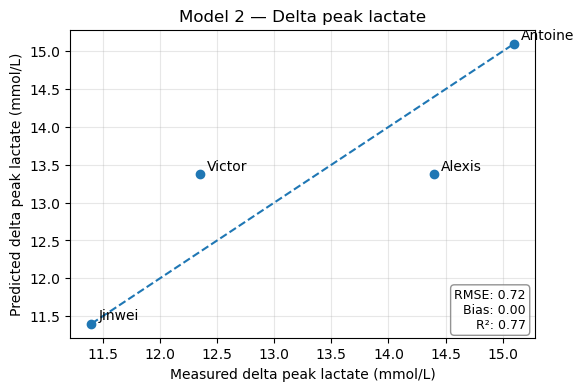

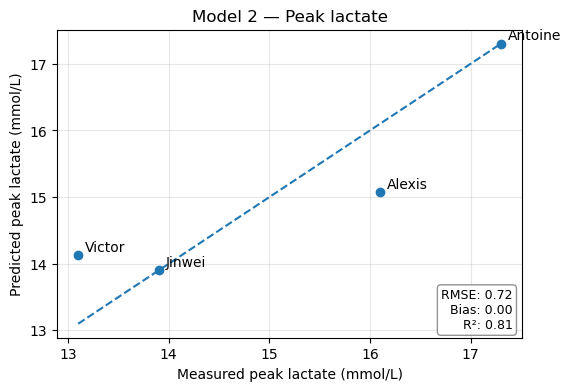


===== FINAL MODEL 2 TABLE =====
        id     AUC_30s  tau_SmO2  dSmO2_max  slope_0_10  La_baseline  \
0   Alexis  210.286007  7.022233   9.623775   -0.551072         1.70   
1  Antoine  372.110247  5.300891  15.782467   -0.301603         2.20   
2   Jinwei  155.060200  0.100000   6.302000   -0.114292         2.50   
3   Victor  210.286007  7.022233   9.623775   -0.551072         0.75   

   Delta_La_peak  delta_peak_pred  La_peak  La_peak_pred  
0          14.40           13.375     16.1        15.075  
1          15.10           15.100     17.3        17.300  
2          11.40           11.400     13.9        13.900  
3          12.35           13.375     13.1        14.125  


In [7]:
# 7) SCATTER PLOT — DELTA PEAK
plt.figure(figsize=(6, 4))

plt.scatter(y2, df_m2["delta_peak_pred"])

mn = min(y2.min(), df_m2["delta_peak_pred"].min())
mx = max(y2.max(), df_m2["delta_peak_pred"].max())
plt.plot([mn, mx], [mn, mx], "--")

for _, row in df_m2.iterrows():
    plt.annotate(
        row["id"],
        (row["Delta_La_peak"], row["delta_peak_pred"]),
        xytext=(5, 3),
        textcoords="offset points"
    )

plt.xlabel("Measured delta peak lactate (mmol/L)")
plt.ylabel("Predicted delta peak lactate (mmol/L)")
plt.title("Model 2 — Delta peak lactate")
plt.grid(True, alpha=0.3)

# metrics box (bottom-right) - delta
bias2 = float(np.mean(df_m2["delta_peak_pred"] - y2))
metrics_txt_delta = f"RMSE: {rmse2:.2f}\nBias: {bias2:.2f}\nR²: {r2_2:.2f}"
ax = plt.gca()
ax.text(
    0.98, 0.02, metrics_txt_delta,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.85)
)

plt.show()


# 8) ACTUAL PEAK LACTATE
plt.figure(figsize=(6, 4))

plt.scatter(df_m2["La_peak"], df_m2["La_peak_pred"])

mn = min(df_m2["La_peak"].min(), df_m2["La_peak_pred"].min())
mx = max(df_m2["La_peak"].max(), df_m2["La_peak_pred"].max())
plt.plot([mn, mx], [mn, mx], "--")

for _, row in df_m2.iterrows():
    plt.annotate(
        row["id"],
        (row["La_peak"], row["La_peak_pred"]),
        xytext=(5, 3),
        textcoords="offset points"
    )

plt.xlabel("Measured peak lactate (mmol/L)")
plt.ylabel("Predicted peak lactate (mmol/L)")
plt.title("Model 2 — Peak lactate")
plt.grid(True, alpha=0.3)

# metrics box (bottom-right) - peak
y_peak = df_m2["La_peak"].to_numpy(float)
y_peak_pred = df_m2["La_peak_pred"].to_numpy(float)

rmse_peak = float(np.sqrt(mean_squared_error(y_peak, y_peak_pred)))
bias_peak = float(np.mean(y_peak_pred - y_peak))
r2_peak = float(r2_score(y_peak, y_peak_pred))

metrics_txt_peak = f"RMSE: {rmse_peak:.2f}\nBias: {bias_peak:.2f}\nR²: {r2_peak:.2f}"
ax = plt.gca()
ax.text(
    0.98, 0.02, metrics_txt_peak,
    transform=ax.transAxes,
    ha="right", va="bottom",
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.85)
)

plt.show()


# 9) FINAL RESULTS TABLE

print("\n===== FINAL MODEL 2 TABLE =====")
print(df_m2[[
    "id",
    "AUC_30s",
    "tau_SmO2",
    "dSmO2_max",
    "slope_0_10",
    "La_baseline",
    "Delta_La_peak",
    "delta_peak_pred",
    "La_peak",
    "La_peak_pred"
]])